# 06 모델 - LightGBM · XGBoost + 비즈니스 임팩트

## 비교 실험
| 모델 | 데이터 | 목적 |
|---|---|---|
| LGB-A | application_train만 | 베이스라인 |
| LGB-B | + bureau 집계 변수 | bureau 효과 검증 |
| XGB-B | + bureau (XGBoost) | LGB와 비교 |

## 평가 기준
- AUC + AUPRC (부도율 8% 불균형이라 AUPRC가 더 중요)
- 임계값 시뮬 표: 임계값 0.05~0.5에서 거절률·승인 후 부도율·기대 손실

## 산출물
- `outputs/models/lgbm_with_bureau.pkl`
- `outputs/tables/06_model_metrics.csv`
- `outputs/tables/06_threshold_simulation.csv`
- `outputs/tables/06_scored_data.csv` (Tableau 입력용)
- `outputs/figures/06_roc_pr.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
import xgboost as xgb
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# 한글 폰트 (Windows)
mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

OUT_TBL = Path("../outputs/tables")
OUT_FIG = Path("../outputs/figures")
OUT_MDL = Path("../outputs/models")
OUT_MDL.mkdir(parents=True, exist_ok=True)

# 데이터 로딩
df = pd.read_parquet(OUT_TBL / "03_application_with_bureau.parquet")
seg = pd.read_csv(OUT_TBL / "05_segments.csv")
df = df.merge(seg[["SK_ID_CURR", "rule_segment"]], on="SK_ID_CURR", how="left")

print(f"Shape: {df.shape}")
print(f"부도율: {df['TARGET'].mean()*100:.2f}%")

Shape: (307511, 181)
부도율: 8.07%


In [2]:
# 범주형 → category dtype
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

# 변수 셋 정의
exclude = {"SK_ID_CURR", "TARGET", "rule_segment", "km_segment",
           "has_bureau", "bureau_count_filled"}

app_cols  = [c for c in df.columns if not c.startswith("bureau_") and c not in exclude]
bureau_cols = [c for c in df.columns if c.startswith("bureau_") or c in ("has_bureau", "bureau_count_filled")]

# rule_segment 추가
df["rule_segment"] = df["rule_segment"].astype("category")

X_A = df[app_cols + ["rule_segment"]]
X_B = df[app_cols + bureau_cols + ["rule_segment"]]
y   = df["TARGET"]

X_A_tr, X_A_te, y_tr, y_te = train_test_split(X_A, y, test_size=0.2, random_state=42, stratify=y)
X_B_tr, X_B_te, _,   _    = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {y_tr.shape[0]}  Test: {y_te.shape[0]}")
print(f"X_A 변수 수: {X_A.shape[1]}  |  X_B 변수 수: {X_B.shape[1]}")

Train: 246008  Test: 61503
X_A 변수 수: 121  |  X_B 변수 수: 179


## Step 1. LGB-A - application only (베이스라인)

In [3]:
lgb_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_a = lgb.LGBMClassifier(**lgb_params)
lgb_a.fit(
    X_A_tr, y_tr,
    eval_set=[(X_A_te, y_te)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

proba_a = lgb_a.predict_proba(X_A_te)[:, 1]
auc_a   = roc_auc_score(y_te, proba_a)
auprc_a = average_precision_score(y_te, proba_a)
print(f"\nLGB-A  →  AUC: {auc_a:.4f}  |  AUPRC: {auprc_a:.4f}")

[100]	valid_0's binary_logloss: 0.246263
[200]	valid_0's binary_logloss: 0.245234
[300]	valid_0's binary_logloss: 0.245117

LGB-A  →  AUC: 0.7605  |  AUPRC: 0.2520


## Step 2. LGB-B - +bureau 집계 변수

In [4]:
lgb_b = lgb.LGBMClassifier(**lgb_params)
lgb_b.fit(
    X_B_tr, y_tr,
    eval_set=[(X_B_te, y_te)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

proba_b = lgb_b.predict_proba(X_B_te)[:, 1]
auc_b   = roc_auc_score(y_te, proba_b)
auprc_b = average_precision_score(y_te, proba_b)
print(f"LGB-B  →  AUC: {auc_b:.4f}  |  AUPRC: {auprc_b:.4f}")
print(f"bureau Lift  →  ΔAUC: {auc_b - auc_a:+.4f}  |  ΔAUPRC: {auprc_b - auprc_a:+.4f}")

[100]	valid_0's binary_logloss: 0.244883
[200]	valid_0's binary_logloss: 0.243324
[300]	valid_0's binary_logloss: 0.243199
LGB-B  →  AUC: 0.7663  |  AUPRC: 0.2628
bureau Lift  →  ΔAUC: +0.0057  |  ΔAUPRC: +0.0108


## Step 3. XGB-B - +bureau (LGB과 비교)

In [7]:
# XGBoost: category 직접 처리 제한 → label encode
X_B_tr_enc = X_B_tr.copy()
X_B_te_enc = X_B_te.copy()

for col in X_B_tr_enc.select_dtypes(include="category").columns:
    le = LabelEncoder()
    X_B_tr_enc[col] = le.fit_transform(X_B_tr_enc[col].astype(str))
    X_B_te_enc[col] = X_B_te_enc[col].astype(str).map(
        lambda v, le=le: le.transform([v])[0] if v in le.classes_ else -1
    )

xgb_b = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    reg_alpha=0.1,
    reg_lambda=0.1,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_b.fit(
    X_B_tr_enc, y_tr,
    eval_set=[(X_B_te_enc, y_te)],
    verbose=False,
)

proba_xb = xgb_b.predict_proba(X_B_te_enc)[:, 1]
auc_xb   = roc_auc_score(y_te, proba_xb)
auprc_xb = average_precision_score(y_te, proba_xb)
print(f"XGB-B  →  AUC: {auc_xb:.4f}  |  AUPRC: {auprc_xb:.4f}")

XGB-B  →  AUC: 0.7667  |  AUPRC: 0.2642


## Step 4. 모델 비교 + ROC · PR Curve

In [8]:
metrics = pd.DataFrame([
    {"model": "LGB-A (app only)",  "AUC": auc_a,  "AUPRC": auprc_a},
    {"model": "LGB-B (+bureau)",   "AUC": auc_b,  "AUPRC": auprc_b},
    {"model": "XGB-B (+bureau)",   "AUC": auc_xb, "AUPRC": auprc_xb},
])
metrics.to_csv(OUT_TBL / "06_model_metrics.csv", index=False)
print(metrics.to_string(index=False))

           model      AUC    AUPRC
LGB-A (app only) 0.760535 0.252023
 LGB-B (+bureau) 0.766254 0.262835
 XGB-B (+bureau) 0.766729 0.264247


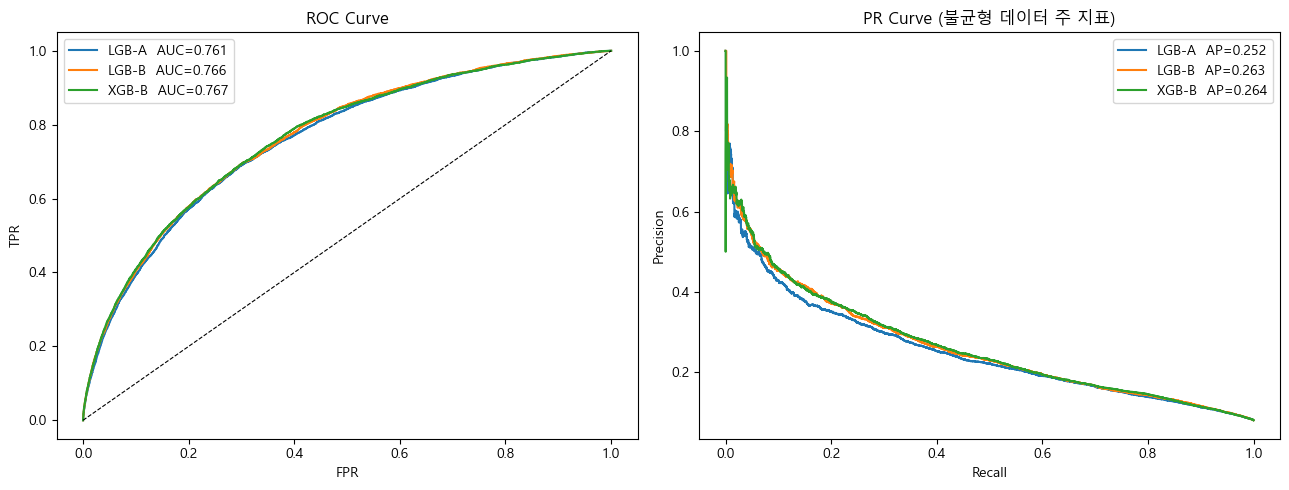

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for proba, name in [(proba_a, "LGB-A"), (proba_b, "LGB-B"), (proba_xb, "XGB-B")]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    axes[0].plot(fpr, tpr, label=f"{name}  AUC={roc_auc_score(y_te, proba):.3f}")

    prec, rec, _ = precision_recall_curve(y_te, proba)
    axes[1].plot(rec, prec, label=f"{name}  AP={average_precision_score(y_te, proba):.3f}")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("FPR");  axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve");  axes[0].legend()

axes[1].set_xlabel("Recall");  axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curve (불균형 데이터 주 지표)");  axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_FIG / "06_roc_pr.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 5. 비즈니스 임팩트 - 임계값 시뮬레이션

In [10]:
# 가정: 부도 1건당 평균 손실 5천만원 (단순화)
LOSS_PER_DEFAULT = 50_000_000

thresholds = np.arange(0.05, 0.55, 0.05)
sim = []

for thr in thresholds:
    pred = (proba_b >= thr).astype(int)   # 1 = 거절
    n_test      = len(y_te)
    n_reject    = pred.sum()
    reject_rate = n_reject / n_test

    approved_mask     = pred == 0
    approved_defaults = y_te[approved_mask].sum()
    approved_default_rate = (
        approved_defaults / approved_mask.sum() if approved_mask.sum() > 0 else 0
    )

    caught_defaults = y_te[pred == 1].sum()          # 거절로 막은 실제 부도
    expected_loss   = approved_defaults * LOSS_PER_DEFAULT / 1e8   # 억원

    sim.append({
        "threshold":              round(thr, 2),
        "거절률(%)": round(reject_rate * 100, 1),
        "승인후_부도율(%)": round(approved_default_rate * 100, 2),
        "차단_부도건수":          int(caught_defaults),
        "잔존_기대손실(억원)":    round(expected_loss, 1),
    })

sim_df = pd.DataFrame(sim)
sim_df.to_csv(OUT_TBL / "06_threshold_simulation.csv", index=False)
print(sim_df.to_string(index=False))

 threshold  거절률(%)  승인후_부도율(%)  차단_부도건수  잔존_기대손실(억원)
      0.05    50.5        2.67     4152        406.5
      0.10    24.6        4.30     2970        997.5
      0.15    13.8        5.36     2123       1421.0
      0.20     8.3        6.03     1562       1701.5
      0.25     5.1        6.57     1132       1916.5
      0.30     3.2        6.98      809       2078.0
      0.35     2.0        7.34      537       2214.0
      0.40     1.2        7.57      367       2299.0
      0.45     0.7        7.74      242       2361.5
      0.50     0.4        7.87      145       2410.0


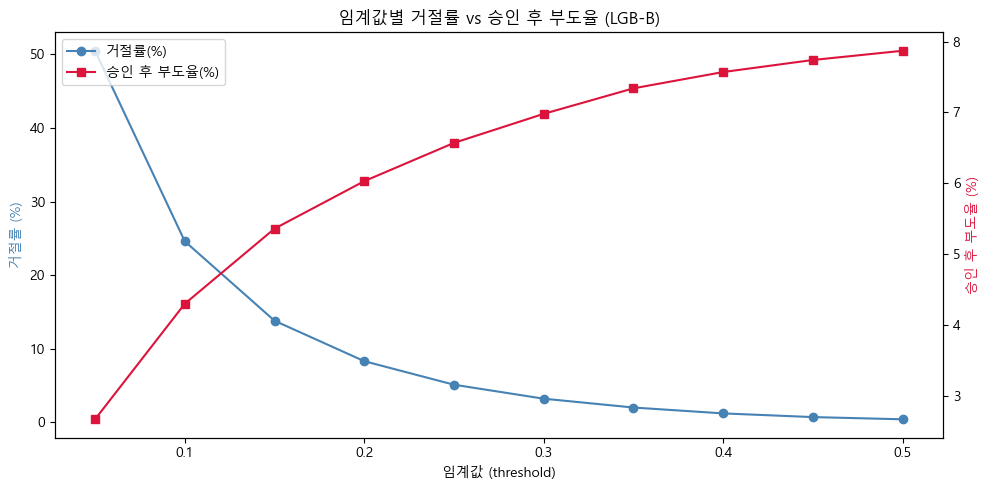

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.plot(sim_df["threshold"], sim_df["거절률(%)"],
         color="steelblue", marker="o", label="거절률(%)")
ax2.plot(sim_df["threshold"], sim_df["승인후_부도율(%)"],
         color="crimson",   marker="s", label="승인 후 부도율(%)")

ax1.set_xlabel("임계값 (threshold)")
ax1.set_ylabel("거절률 (%)",        color="steelblue")
ax2.set_ylabel("승인 후 부도율 (%)", color="crimson")
ax1.set_title("임계값별 거절률 vs 승인 후 부도율 (LGB-B)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(OUT_FIG / "06_threshold_simulation.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 6. 모델 저장 + scored data export

In [12]:
with open(OUT_MDL / "lgbm_with_bureau.pkl", "wb") as f:
    pickle.dump(lgb_b, f)
print("모델 저장 완료: outputs/models/lgbm_with_bureau.pkl")

모델 저장 완료: outputs/models/lgbm_with_bureau.pkl


In [13]:
# 전체 데이터 예측 점수 (Tableau 대시보드 입력용)
full_score = lgb_b.predict_proba(X_B)[:, 1]
df["risk_score"] = full_score

scored = df[["SK_ID_CURR", "TARGET", "risk_score", "rule_segment"]].copy()
scored.to_csv(OUT_TBL / "06_scored_data.csv", index=False)
print(f"저장 완료: {len(scored)} rows → outputs/tables/06_scored_data.csv")
scored.head()

저장 완료: 307511 rows → outputs/tables/06_scored_data.csv


,SK_ID_CURR,TARGET,risk_score,rule_segment
0,100002,1,0.389864,S2: 신생 차주 (저연령+단기고용)
1,100003,0,0.023795,S5: 우량 차주 (고신용)
2,100004,0,0.029789,S4: 안정 차주 (고연령+양호)
3,100006,0,0.064770,S4: 안정 차주 (고연령+양호)
4,100007,0,0.072638,S6: 보통 (분류 외)


## 결론

### 모델 성능
| 모델 | AUC | AUPRC |
|---|---|---|
| LGB-A (app only) | 0.761 | 0.252 |
| LGB-B (+bureau)  | 0.766 | 0.263 |
| XGB-B (+bureau)  | 0.767 | 0.264 |

- bureau 변수 추가 효과: ΔAUC +0.006, ΔAUPRC +0.011. 수치는 작지만 03·04의 인과 분석과 일관된 방향
- LGB vs XGB 차이 0.001로 거의 동일. 학습 속도 우위인 LGB-B를 최종 모델로 선택
- AUC 0.766은 하이퍼파라미터 튜닝 없는 베이스라인 치고 준수한 수준

### 임계값 시뮬레이션 (LGB-B 기준)
- 보수적 (0.05): 거절률 50.5%, 승인 후 부도율 2.67%, 차단 4,152건
- 균형 (0.10): 거절률 24.6%, 승인 후 부도율 4.30%, 차단 2,970건 (권장)
- 표준 (0.20): 거절률 8.3%, 승인 후 부도율 6.03%, 차단 1,562건
- 임계값은 경영진의 리스크 appetite에 따라 결정. 모델은 그 결정을 수치화해 지원하는 도구.

### 다음 단계 (07_shap)
- LGB-B 기준 Top 변수 SHAP 해석. "왜 이 사람이 위험한가"를 도메인 언어로 번역
- bureau 변수가 SHAP Top 7 안에 들어오는지 확인 (03·04 narrative 연결)